In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [4]:
from src.pdf_reader import extract_text_from_pdf

text = extract_text_from_pdf("../data/raw/book.pdf")

print(text[:2000])


PRAISE FOR
A COUNTRY DOCTOR’S NOTEBOOK
“This book has a freshness and liveliness … an epic quality because of the background 
Russia’s vastness, the great distances, the weight of the ignorance, the need.”
—DORIS LESSI
“These straightforward yet extraordinary sketches gain their strength from also being th
account of a young man’s growth. One begins to see that he became a novelist not becau
he had material but because he was storing up passion and temperament.”
—V.S. PRITCHETT, NEW STATESM
“Stories as keen and bright as a scalpel … Courage shines from every angle of th
profoundly human collection by the greatest of modern Russian writers.”
—SUNDAY TIM
“Bulgakov casts a wonderfully wry, self-deprecating humour. His compassion for huma
folly is unfailing … These stories stand testament both to human resilience and 
remarkable literary talent.”
—THE INDEPENDE

A COUNTRY DOCTOR’S NOTEBOOK
MIKHAIL BULGAKOV (1891–1940) was born in Kiev, one of seven children born to a
university lecturer a

In [5]:
from src.pdf_reader import extract_text_from_pdf
from src.text_processor import process_text

text = extract_text_from_pdf("../data/raw/book.pdf")

tokens = process_text(text)

tokens[:20]

[{'word': 'praise', 'lemma': 'praise', 'pos': 'VERB', 'is_stop': False},
 {'word': 'for', 'lemma': 'for', 'pos': 'ADP', 'is_stop': True},
 {'word': 'a', 'lemma': 'a', 'pos': 'DET', 'is_stop': True},
 {'word': 'country', 'lemma': 'country', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'doctor', 'lemma': 'doctor', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'notebook', 'lemma': 'notebook', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'this', 'lemma': 'this', 'pos': 'DET', 'is_stop': True},
 {'word': 'book', 'lemma': 'book', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'has', 'lemma': 'have', 'pos': 'VERB', 'is_stop': True},
 {'word': 'a', 'lemma': 'a', 'pos': 'DET', 'is_stop': True},
 {'word': 'freshness', 'lemma': 'freshness', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'and', 'lemma': 'and', 'pos': 'CCONJ', 'is_stop': True},
 {'word': 'liveliness',
  'lemma': 'liveliness',
  'pos': 'NOUN',
  'is_stop': False},
 {'word': 'an', 'lemma': 'an', 'pos': 'DET', 'is_stop': True},
 {'word': 'epic'

In [6]:
len(tokens)

47860

In [9]:
from src.vocab_builder import build_vocabulary

vocab_df = build_vocabulary(tokens, min_frequency=2)
vocab_df.head(20)

,lemma,pos,frequency
0,say,VERB,173
1,come,VERB,145
2,woman,NOUN,126
3,doctor,NOUN,120
4,eye,NOUN,112
5,time,NOUN,105
6,look,VERB,94
7,feel,VERB,91
8,think,VERB,91
9,man,NOUN,82


In [10]:
vocab_df.shape

(2383, 3)

In [12]:
vocab_df.sample(20)

,lemma,pos,frequency
1536,writing,NOUN,3
1458,speckle,VERB,3
1699,crave,VERB,2
202,listen,VERB,16
136,cut,VERB,21
818,roar,VERB,5
2306,twist,VERB,2
948,gravely,ADV,4
176,suppose,VERB,18
392,disappear,VERB,9


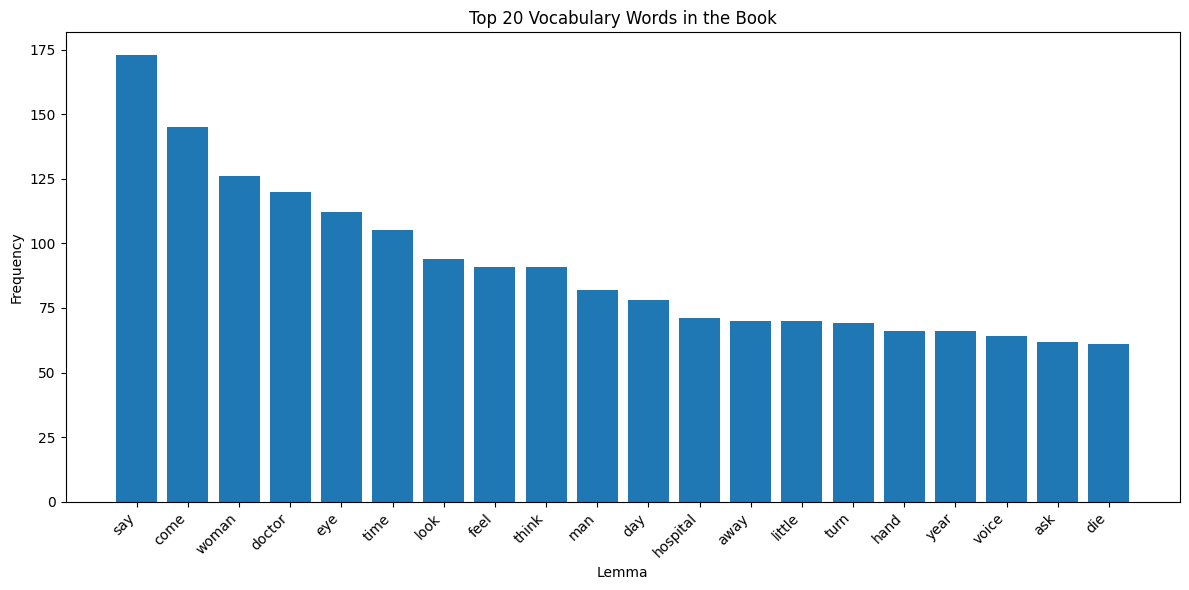

In [14]:
import matplotlib.pyplot as plt

top_n = 20
top_vocab = vocab_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top_vocab["lemma"], top_vocab["frequency"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Frequency")
plt.title("Top 20 Vocabulary Words in the Book")
plt.tight_layout()
plt.show()

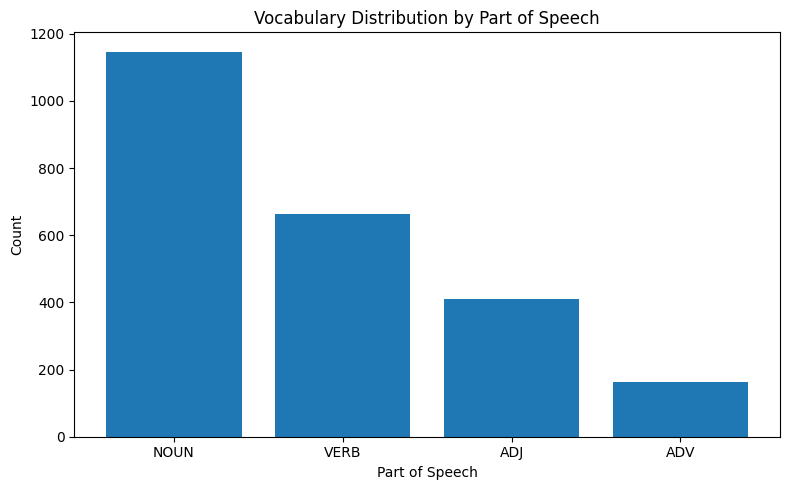

In [15]:
pos_counts = vocab_df["pos"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(pos_counts.index, pos_counts.values)
plt.xlabel("Part of Speech")
plt.ylabel("Count")
plt.title("Vocabulary Distribution by Part of Speech")
plt.tight_layout()
plt.show()

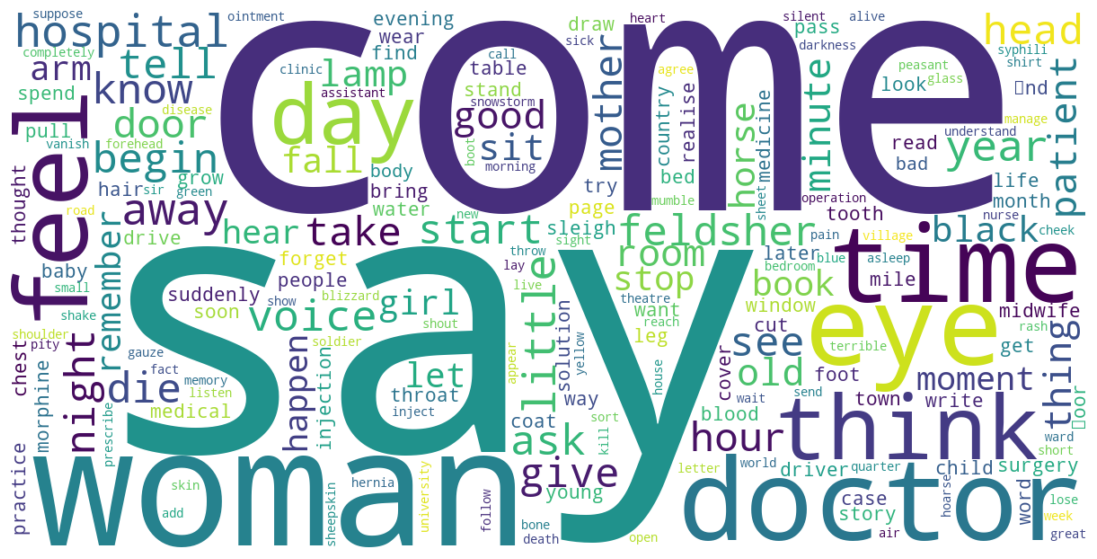

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

freq_dict = dict(zip(vocab_df["lemma"], vocab_df["frequency"]))

wordcloud = WordCloud(width=1200, height=600, background_color="white").generate_from_frequencies(freq_dict)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()